# **09 - Temporal Aggregation Results Review**

Use this notebook to inspect the current best temporal-alert results after simple post-processing sweeps. It reads local artifacts from `models/reports/`, `outputs/predictions/`, and optionally `mlflow.db`.

## **Setup**

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

REPORTS_DIR = PROJECT_ROOT / "models" / "reports"
PREDICTIONS_DIR = PROJECT_ROOT / "outputs" / "predictions"
SAMPLE_PATH = PROJECT_ROOT / "data" / "interim" / "sample_100_videos_splits.csv"
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT

WindowsPath('C:/Users/z004hn4c/Documents/Estudo/LLMOps And AIOps Bootcamp With 8 End To End Projects/nexar-dashcam-collision-prediction')

## **Load Sweep Artifacts**

In [2]:
METHODS = [
    {
        "method": "raw pretrained best",
        "sweep": "temporal_alert_224_pretrained_best_alert_threshold_sweep.csv",
        "risk_scores": "temporal_alert_224_pretrained_best_temporal_risk_scores.csv",
        "threshold_hint": 0.23,
        "min_consecutive_frames": 1,
    },
    {
        "method": "moving average 3s",
        "sweep": "temporal_alert_224_pretrained_best_ma3s_alert_threshold_sweep.csv",
        "risk_scores": "temporal_alert_224_pretrained_best_ma3s_temporal_risk_scores.csv",
        "threshold_hint": 0.17,
        "min_consecutive_frames": 1,
    },
    {
        "method": "moving average 5s",
        "sweep": "temporal_alert_224_pretrained_best_ma5s_alert_threshold_sweep.csv",
        "risk_scores": "temporal_alert_224_pretrained_best_ma5s_temporal_risk_scores.csv",
        "threshold_hint": 0.13,
        "min_consecutive_frames": 1,
    },
    {
        "method": "rolling max 3s",
        "sweep": "temporal_alert_224_pretrained_best_rmax3s_alert_threshold_sweep.csv",
        "risk_scores": "temporal_alert_224_pretrained_best_rmax3s_temporal_risk_scores.csv",
        "threshold_hint": 0.23,
        "min_consecutive_frames": 1,
    },
    {
        "method": "2 consecutive frames",
        "sweep": "temporal_alert_224_pretrained_best_consecutive2_alert_threshold_sweep.csv",
        "risk_scores": "temporal_alert_224_pretrained_best_consecutive2_temporal_risk_scores.csv",
        "threshold_hint": 0.13,
        "min_consecutive_frames": 2,
    },
    {
        "method": "moving average 3s + consecutive 2",
        "sweep": "temporal_alert_224_pretrained_best_ma3s_consecutive2_alert_threshold_sweep.csv",
        "risk_scores": "temporal_alert_224_pretrained_best_ma3s_consecutive2_temporal_risk_scores.csv",
        "threshold_hint": 0.12,
        "min_consecutive_frames": 2,
    },
]


def load_sweep(method_config: dict) -> pd.DataFrame:
    path = REPORTS_DIR / method_config["sweep"]
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    df["method"] = method_config["method"]
    df["sweep_path"] = str(path.relative_to(PROJECT_ROOT))
    return df


sweeps_df = pd.concat([load_sweep(config) for config in METHODS], ignore_index=True)
sweeps_df.head()

,threshold,videos,positive_videos,negative_videos,predicted_alerts,true_positive_alerts,false_positive_alerts,missed_events,alert_precision,alert_recall,false_alarm_rate,missed_event_rate,mean_predicted_lead_time,median_predicted_lead_time,mean_alert_time_error,median_alert_time_error,method,sweep_path
0,0.10,20,10,10,18,8,9,2,0.470588,0.8,0.9,0.2,14.38325,13.7995,-12.241375,-11.552,raw pretrained best,models\reports\temporal_alert_224_pretrained_b...
1,0.11,20,10,10,17,8,8,2,0.500000,0.8,0.8,0.2,14.38325,13.7995,-12.241375,-11.552,raw pretrained best,models\reports\temporal_alert_224_pretrained_b...
2,0.12,20,10,10,16,8,7,2,0.533333,0.8,0.7,0.2,14.38325,13.7995,-12.241375,-11.552,raw pretrained best,models\reports\temporal_alert_224_pretrained_b...
3,0.13,20,10,10,16,8,7,2,0.533333,0.8,0.7,0.2,14.38325,13.7995,-12.241375,-11.552,raw pretrained best,models\reports\temporal_alert_224_pretrained_b...
4,0.14,20,10,10,16,8,7,2,0.533333,0.8,0.7,0.2,14.13325,13.4295,-11.991375,-11.552,raw pretrained best,models\reports\temporal_alert_224_pretrained_b...


## **Operating Points**

In [3]:
def choose_operating_point(sweep_df: pd.DataFrame, min_recall: float) -> pd.Series | None:
    candidates = sweep_df[sweep_df["alert_recall"] >= min_recall].copy()
    if candidates.empty:
        return None
    candidates = candidates.sort_values(
        ["false_alarm_rate", "missed_event_rate", "alert_precision", "mean_alert_time_error"],
        ascending=[True, True, False, False],
    )
    return candidates.iloc[0]


rows = []
for method, method_df in sweeps_df.groupby("method", sort=False):
    for min_recall in [0.7, 0.6, 0.5, 0.4, 0.3]:
        point = choose_operating_point(method_df, min_recall)
        if point is None:
            continue
        rows.append(
            {
                "method": method,
                "min_recall": min_recall,
                "threshold": point["threshold"],
                "precision": point["alert_precision"],
                "recall": point["alert_recall"],
                "false_alarm_rate": point["false_alarm_rate"],
                "missed_event_rate": point["missed_event_rate"],
                "mean_lead_time": point["mean_predicted_lead_time"],
                "mean_alert_error": point["mean_alert_time_error"],
            }
        )

operating_df = pd.DataFrame(rows)
operating_df.sort_values(["min_recall", "false_alarm_rate", "precision"], ascending=[False, True, False])

,method,min_recall,threshold,precision,recall,false_alarm_rate,missed_event_rate,mean_lead_time,mean_alert_error
20,2 consecutive frames,0.7,0.13,0.727273,0.8,0.3,0.2,10.133250,-7.991375
5,moving average 3s,0.7,0.17,0.700000,0.7,0.3,0.3,9.233429,-7.182000
0,raw pretrained best,0.7,0.23,0.666667,0.8,0.4,0.2,9.758250,-7.616375
10,moving average 5s,0.7,0.13,0.666667,0.8,0.4,0.2,9.383250,-7.241375
15,rolling max 3s,0.7,0.23,0.666667,0.8,0.4,0.2,9.758250,-7.616375
25,moving average 3s + consecutive 2,0.7,0.12,0.666667,0.8,0.4,0.2,11.258250,-9.116375
21,2 consecutive frames,0.6,0.13,0.727273,0.8,0.3,0.2,10.133250,-7.991375
6,moving average 3s,0.6,0.17,0.700000,0.7,0.3,0.3,9.233429,-7.182000
11,moving average 5s,0.6,0.16,0.666667,0.6,0.3,0.4,11.073333,-9.300833
1,raw pretrained best,0.6,0.23,0.666667,0.8,0.4,0.2,9.758250,-7.616375


## Compare Methods at Minimum Recall 0.70

In [4]:
min_recall_07_df = (
    operating_df[operating_df["min_recall"] == 0.7]
    .sort_values(["false_alarm_rate", "precision"], ascending=[True, False])
    .reset_index(drop=True)
)
min_recall_07_df

,method,min_recall,threshold,precision,recall,false_alarm_rate,missed_event_rate,mean_lead_time,mean_alert_error
0,2 consecutive frames,0.7,0.13,0.727273,0.8,0.3,0.2,10.133250,-7.991375
1,moving average 3s,0.7,0.17,0.700000,0.7,0.3,0.3,9.233429,-7.182000
2,raw pretrained best,0.7,0.23,0.666667,0.8,0.4,0.2,9.758250,-7.616375
3,moving average 5s,0.7,0.13,0.666667,0.8,0.4,0.2,9.383250,-7.241375
4,rolling max 3s,0.7,0.23,0.666667,0.8,0.4,0.2,9.758250,-7.616375
5,moving average 3s + consecutive 2,0.7,0.12,0.666667,0.8,0.4,0.2,11.258250,-9.116375


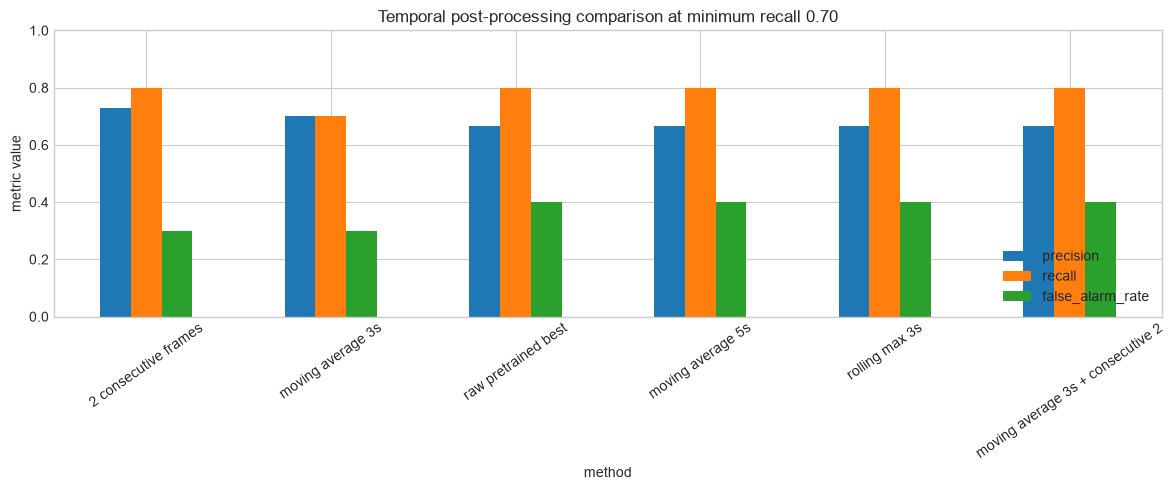

In [5]:
plot_df = min_recall_07_df.set_index("method")[["precision", "recall", "false_alarm_rate"]]
ax = plot_df.plot(kind="bar", figsize=(12, 5), rot=35)
ax.set_ylim(0, 1)
ax.set_ylabel("metric value")
ax.set_title("Temporal post-processing comparison at minimum recall 0.70")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Threshold Curves

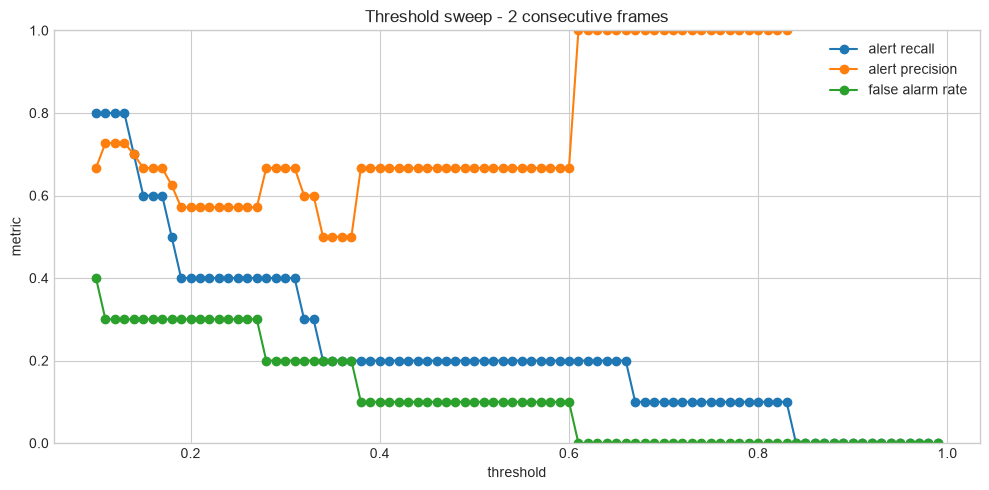

In [6]:
SELECT_METHOD = "2 consecutive frames"

method_df = sweeps_df[sweeps_df["method"] == SELECT_METHOD].copy()
if method_df.empty:
    raise ValueError(f"Unknown method: {SELECT_METHOD}")

plt.figure(figsize=(10, 5))
plt.plot(method_df["threshold"], method_df["alert_recall"], marker="o", label="alert recall")
plt.plot(method_df["threshold"], method_df["alert_precision"], marker="o", label="alert precision")
plt.plot(method_df["threshold"], method_df["false_alarm_rate"], marker="o", label="false alarm rate")
plt.xlabel("threshold")
plt.ylabel("metric")
plt.ylim(0, 1)
plt.title(f"Threshold sweep - {SELECT_METHOD}")
plt.legend()
plt.tight_layout()
plt.show()

## Per-Video Alert Table

In [7]:
def first_alert_time(video_scores: pd.DataFrame, threshold: float, min_consecutive_frames: int = 1):
    sorted_scores = video_scores.sort_values("timestamp")
    above_threshold = sorted_scores["risk_score"] >= threshold
    if min_consecutive_frames <= 1:
        alerts = sorted_scores[above_threshold]
        return None if alerts.empty else float(alerts.iloc[0]["timestamp"])

    consecutive_count = 0
    for timestamp, is_above_threshold in zip(sorted_scores["timestamp"], above_threshold):
        consecutive_count = consecutive_count + 1 if is_above_threshold else 0
        if consecutive_count >= min_consecutive_frames:
            return float(timestamp)
    return None


def build_video_alert_table(method_name: str, threshold: float | None = None) -> pd.DataFrame:
    config = next(config for config in METHODS if config["method"] == method_name)
    threshold = config["threshold_hint"] if threshold is None else threshold
    risk_df = pd.read_csv(PREDICTIONS_DIR / config["risk_scores"], dtype={"id": str})
    sample_df = pd.read_csv(SAMPLE_PATH, dtype={"id": str})
    sample_df = sample_df[sample_df["split"] == "val"].copy()

    records = []
    for _, row in sample_df.iterrows():
        video_scores = risk_df[risk_df["id"] == row["id"]]
        predicted_alert_time = first_alert_time(
            video_scores,
            threshold,
            config["min_consecutive_frames"],
        )
        time_of_alert = float(row["time_of_alert"]) if pd.notna(row["time_of_alert"]) else None
        time_of_event = float(row["time_of_event"]) if pd.notna(row["time_of_event"]) else None
        predicted_lead_time = (
            time_of_event - predicted_alert_time
            if int(row["target"]) == 1 and predicted_alert_time is not None and time_of_event is not None
            else None
        )
        alert_time_error = (
            predicted_alert_time - time_of_alert
            if int(row["target"]) == 1 and predicted_alert_time is not None and time_of_alert is not None
            else None
        )
        records.append(
            {
                "id": row["id"],
                "target": int(row["target"]),
                "threshold": threshold,
                "predicted_alert_time": predicted_alert_time,
                "time_of_alert": time_of_alert,
                "time_of_event": time_of_event,
                "predicted_lead_time": predicted_lead_time,
                "alert_time_error": alert_time_error,
                "max_risk_score": video_scores["risk_score"].max() if not video_scores.empty else None,
            }
        )
    return pd.DataFrame(records)


alert_table_df = build_video_alert_table("2 consecutive frames")
alert_table_df.sort_values(["target", "predicted_alert_time"], ascending=[False, True])

,id,target,threshold,predicted_alert_time,time_of_alert,time_of_event,predicted_lead_time,alert_time_error,max_risk_score
4,00858,1,0.13,1.0,16.633,20.033,19.033,-15.633,0.883155
16,00972,1,0.13,2.0,14.544,15.602,13.602,-12.544,0.476623
12,00733,1,0.13,6.0,11.469,15.194,9.194,-5.469,0.427092
7,00519,1,0.13,8.0,19.033,19.567,11.567,-11.033,0.772786
15,00082,1,0.13,8.0,17.433,20.167,12.167,-9.433,0.378486
10,00534,1,0.13,10.0,17.715,19.644,9.644,-7.715,0.520017
0,00364,1,0.13,15.0,19.447,20.427,5.427,-4.447,0.697866
1,00640,1,0.13,20.0,17.657,20.432,0.432,2.343,0.455659
2,00783,1,0.13,NaN,20.350,21.265,NaN,NaN,0.084127
17,00461,1,0.13,NaN,8.000,10.100,NaN,NaN,0.212689


## Risk Curve for One Video

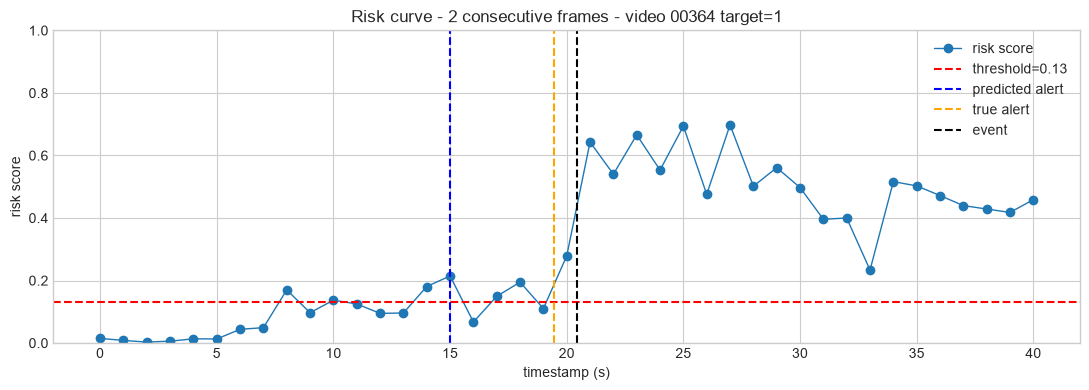

In [8]:
sample_df = pd.read_csv(SAMPLE_PATH, dtype={"id": str})
val_positive_ids = sample_df[(sample_df["split"] == "val") & (sample_df["target"] == 1)]["id"].tolist()
val_negative_ids = sample_df[(sample_df["split"] == "val") & (sample_df["target"] == 0)]["id"].tolist()

SELECT_VIDEO_ID = val_positive_ids[0]
SELECT_METHOD = "2 consecutive frames"

config = next(config for config in METHODS if config["method"] == SELECT_METHOD)
risk_df = pd.read_csv(PREDICTIONS_DIR / config["risk_scores"], dtype={"id": str})
video_scores = risk_df[risk_df["id"] == SELECT_VIDEO_ID].sort_values("timestamp")
video_row = sample_df[sample_df["id"] == SELECT_VIDEO_ID].iloc[0]
threshold = config["threshold_hint"]
predicted_alert_time = first_alert_time(video_scores, threshold, config["min_consecutive_frames"])

plt.figure(figsize=(11, 4))
plt.plot(video_scores["timestamp"], video_scores["risk_score"], marker="o", linewidth=1, label="risk score")
plt.axhline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.2f}")
if predicted_alert_time is not None:
    plt.axvline(predicted_alert_time, color="blue", linestyle="--", label="predicted alert")
if int(video_row["target"]) == 1:
    plt.axvline(float(video_row["time_of_alert"]), color="orange", linestyle="--", label="true alert")
    plt.axvline(float(video_row["time_of_event"]), color="black", linestyle="--", label="event")
plt.title(f"Risk curve - {SELECT_METHOD} - video {SELECT_VIDEO_ID} target={video_row['target']}")
plt.xlabel("timestamp (s)")
plt.ylabel("risk score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## Raw vs Best Post-Processing

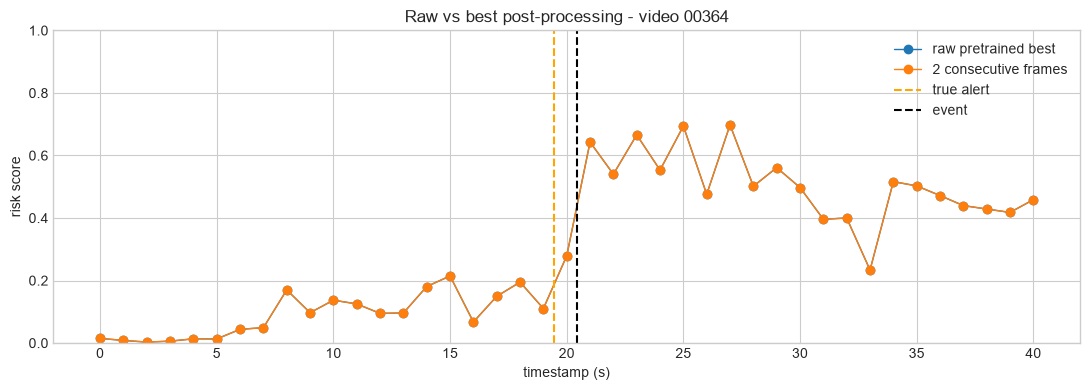

In [9]:
VIDEO_ID = SELECT_VIDEO_ID
compare_methods = ["raw pretrained best", "2 consecutive frames"]

plt.figure(figsize=(11, 4))
for method_name in compare_methods:
    config = next(config for config in METHODS if config["method"] == method_name)
    risk_df = pd.read_csv(PREDICTIONS_DIR / config["risk_scores"], dtype={"id": str})
    video_scores = risk_df[risk_df["id"] == VIDEO_ID].sort_values("timestamp")
    plt.plot(video_scores["timestamp"], video_scores["risk_score"], marker="o", linewidth=1, label=method_name)

video_row = sample_df[sample_df["id"] == VIDEO_ID].iloc[0]
if int(video_row["target"]) == 1:
    plt.axvline(float(video_row["time_of_alert"]), color="orange", linestyle="--", label="true alert")
    plt.axvline(float(video_row["time_of_event"]), color="black", linestyle="--", label="event")
plt.title(f"Raw vs best post-processing - video {VIDEO_ID}")
plt.xlabel("timestamp (s)")
plt.ylabel("risk score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## Optional: MLflow Runs

In [10]:
try:
    import mlflow

    mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.as_posix()}")
    experiments = mlflow.search_experiments()
    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id for experiment in experiments],
        output_format="pandas",
    )
    wanted_cols = [
        "start_time",
        "status",
        "tags.stage",
        "tags.experiment_name",
        "params.aggregation",
        "params.aggregation_window_seconds",
        "params.min_consecutive_frames",
        "metrics.min_recall_0_7_threshold",
        "metrics.min_recall_0_7_alert_precision",
        "metrics.min_recall_0_7_alert_recall",
        "metrics.min_recall_0_7_false_alarm_rate",
    ]
    existing_cols = [column for column in wanted_cols if column in runs.columns]
    runs[existing_cols].sort_values("start_time", ascending=False).head(12)
except Exception as exc:
    print(f"MLflow runs could not be loaded: {exc}")

## Reproduction Commands

```powershell
.\venv\Scripts\python.exe scripts\sweep_alert_thresholds.py --experiment-name temporal_alert_224_pretrained_best --sample-csv data\interim\sample_100_videos_splits.csv --split val --min-consecutive-frames 2
.\venv\Scripts\python.exe scripts\sweep_alert_thresholds.py --experiment-name temporal_alert_224_pretrained_best --sample-csv data\interim\sample_100_videos_splits.csv --split val --aggregation moving_average --aggregation-window-seconds 3
.\venv\Scripts\python.exe scripts\sweep_alert_thresholds.py --experiment-name temporal_alert_224_pretrained_best --sample-csv data\interim\sample_100_videos_splits.csv --split val --aggregation rolling_max --aggregation-window-seconds 3
```
